# Two Layer Neural Network - Cars vs Bike Classification
This notebook loads images from:
`ASSIGNMENT/transport/cars/` → label 1
`ASSIGNMENT/transport/bike/` → label 0
Implements a 2-layer neural network 



In [3]:

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


## 1. Load Dataset

In [4]:

def load_images_from_folder(folder, label, image_size=(64,64)):
    X = []
    Y = []
    
    for filename in os.listdir(folder):
        if filename.endswith(".bmp"):
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).convert("RGB")
            img = img.resize(image_size)
            img_array = np.array(img)
            X.append(img_array)
            Y.append(label)
    
    return X, Y


base_path = "transport"

cars_path = os.path.join(base_path, "cars")
bike_path = os.path.join(base_path, "bike")

X_cars, Y_cars = load_images_from_folder(cars_path, 1)
X_bike, Y_bike = load_images_from_folder(bike_path, 0)

X = np.array(X_cars + X_bike)
Y = np.array(Y_cars + Y_bike)

print("Total examples:", X.shape[0])


Total examples: 785


## 2. Preprocessing

In [5]:

m = X.shape[0]

X_flatten = X.reshape(m, -1).T
X = X_flatten / 255.

Y = Y.reshape(1, m)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (12288, 785)
Y shape: (1, 785)


## 3. Neural Network Functions

In [6]:

def sigmoid(Z):
    return 1/(1+np.exp(-Z)), Z

def relu(Z):
    return np.maximum(0,Z), Z

def relu_backward(dA, cache):
    Z = cache
    dZ = np.array(dA, copy=True)
    dZ[Z<=0] = 0
    return dZ

def sigmoid_backward(dA, cache):
    Z = cache
    s = 1/(1+np.exp(-Z))
    return dA*s*(1-s)

def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(1)
    W1 = np.random.randn(n_h,n_x)*0.01
    b1 = np.zeros((n_h,1))
    W2 = np.random.randn(n_y,n_h)*0.01
    b2 = np.zeros((n_y,1))
    return {"W1":W1,"b1":b1,"W2":W2,"b2":b2}

def forward_propagation(X, parameters):
    W1,b1,W2,b2 = parameters["W1"],parameters["b1"],parameters["W2"],parameters["b2"]
    Z1 = np.dot(W1,X)+b1
    A1,cache1 = relu(Z1)
    Z2 = np.dot(W2,A1)+b2
    A2,cache2 = sigmoid(Z2)
    cache = (Z1,A1,W1,b1,Z2,A2,W2,b2)
    return A2,cache

def compute_cost(A2,Y):
    m = Y.shape[1]
    return -1/m*np.sum(Y*np.log(A2)+(1-Y)*np.log(1-A2))

def backward_propagation(X,Y,cache):
    m = X.shape[1]
    Z1,A1,W1,b1,Z2,A2,W2,b2 = cache
    
    dZ2 = A2-Y
    dW2 = 1/m*np.dot(dZ2,A1.T)
    db2 = 1/m*np.sum(dZ2,axis=1,keepdims=True)
    
    dA1 = np.dot(W2.T,dZ2)
    dZ1 = relu_backward(dA1,Z1)
    dW1 = 1/m*np.dot(dZ1,X.T)
    db1 = 1/m*np.sum(dZ1,axis=1,keepdims=True)
    
    return {"dW1":dW1,"db1":db1,"dW2":dW2,"db2":db2}

def update_parameters(parameters,grads,learning_rate):
    parameters["W1"] -= learning_rate*grads["dW1"]
    parameters["b1"] -= learning_rate*grads["db1"]
    parameters["W2"] -= learning_rate*grads["dW2"]
    parameters["b2"] -= learning_rate*grads["db2"]
    return parameters

def two_layer_model(X,Y,n_h=7,num_iterations=2500,learning_rate=0.0075):
    n_x = X.shape[0]
    n_y = 1
    parameters = initialize_parameters(n_x,n_h,n_y)
    
    for i in range(num_iterations):
        A2,cache = forward_propagation(X,parameters)
        cost = compute_cost(A2,Y)
        grads = backward_propagation(X,Y,cache)
        parameters = update_parameters(parameters,grads,learning_rate)
        
        if i%100==0:
            print("Cost after iteration",i,":",cost)
            
    return parameters

def predict(X,parameters):
    A2,_ = forward_propagation(X,parameters)
    return (A2>0.5)


## 4. Train Model

In [8]:

parameters = two_layer_model(X,Y,n_h=10,num_iterations=700)

predictions = predict(X,parameters)
accuracy = np.mean(predictions==Y)*100

print("Training Accuracy:",accuracy,"%")


Cost after iteration 0 : 0.694675280006576
Cost after iteration 100 : 0.6758562856708475
Cost after iteration 200 : 0.6686158100901748
Cost after iteration 300 : 0.6561577742881315
Cost after iteration 400 : 0.6381998564396496
Cost after iteration 500 : 0.6179841851236685
Cost after iteration 600 : 0.5961831871753761
Training Accuracy: 71.46496815286623 %


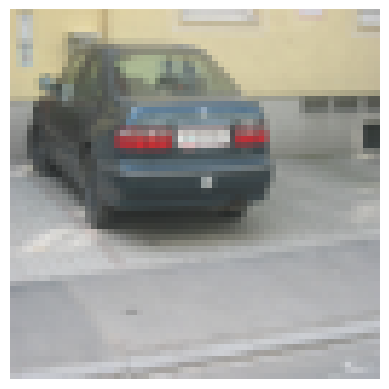

Raw Prediction Value: [[ True]]
Model says: Car


In [9]:
sample_path = "transport/cars/carsgraz_001.bmp"

img = Image.open(sample_path).convert("RGB")
img = img.resize((64,64))
img_array = np.array(img)

plt.imshow(img)
plt.axis("off")
plt.show()

x = img_array.reshape(1, -1).T / 255.

prediction = predict(x, parameters)

print("Raw Prediction Value:", prediction)

if prediction == 1:
    print("Model says: Car")
else:
    print("Model says: Bike")